# Web Intelligence: Single-Site RAG Evaluation

Evaluates retrieval + faithfulness for **one site** with charts and metric tables.

**Change `TARGET_URL` below** to any URL already indexed in a session.

In [1]:
import sys, os, json, re, time, datetime
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='whitegrid', palette='muted')

BACKEND_DIR = Path('.').resolve()
DATA_DIR = BACKEND_DIR.parent / 'data'
sys.path.insert(0, str(BACKEND_DIR))

from dotenv import load_dotenv
load_dotenv(BACKEND_DIR / '.env')

from embeddings import EmbeddingStore
from rag import answer_question

STORE = EmbeddingStore(DATA_DIR / 'faiss_index')
print('EmbeddingStore ready.')

c:\Users\shiva\miniforge3\envs\webin\lib\site-packages\pinecone\data\index.py:1: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


EmbeddingStore ready.


## 1. Configure Target Site

Set `TARGET_URL` to any URL already processed. The notebook resolves its session automatically.

In [2]:
# ── CONFIGURE THIS ────────────────────────────────────────────────────────────
TARGET_URL = 'https://www.aboutamazon.com/what-we-do'  # add url
TOP_K      = 5                             # chunks to retrieve per query
# ─────────────────────────────────────────────────────────────────────────────

# Auto-resolve session from sessions directory
def find_session(url: str) -> dict | None:
    for p in sorted((DATA_DIR / 'sessions').glob('*.json')):
        try:
            data = json.loads(p.read_text(encoding='utf-8'))
            if any(url.rstrip('/') in u for u in data.get('urls', [])):
                return data
        except Exception:
            pass
    return None

session = find_session(TARGET_URL)
assert session, f'No session found for {TARGET_URL}. Run /api/process first.'

SESSION_ID = session['session_id']
SITE_LABEL = TARGET_URL.split('//')[-1].split('/')[0]

print(f'Site      : {SITE_LABEL}')
print(f'Session   : {SESSION_ID}')
print(f'Pages     : {session["page_count"]}')
print(f'Chunks    : {len(session["chunks"])}')
print(f'URLs      : {session["urls"]}')

Site      : www.aboutamazon.com
Session   : 681da379025d9e67
Pages     : 50
Chunks    : 164
URLs      : ['https://www.aboutamazon.com/what-we-do']


## 2. Eval Questions

10 questions auto-seeded for known sites. For a new site, edit `EVAL_QA` directly.

In [3]:
# Preset Q&A banks per known site (extend freely)
_PRESETS = {
    'aboutamazon.com': [
        {'q': 'What does Amazon do as a company?',
         'gt': 'Amazon builds and operates businesses focused on e-commerce, cloud computing, devices, and digital services.',
         'kw': ['ecommerce', 'cloud', 'devices', 'services', 'businesses']},
        {'q': 'What is Amazon Web Services (AWS)?',
         'gt': 'AWS is Amazon’s cloud computing platform providing infrastructure and services to businesses.',
         'kw': ['aws', 'cloud', 'infrastructure', 'services']},
        {'q': 'What kinds of products and services does Amazon offer?',
         'gt': 'Amazon offers retail products, digital content, cloud services, smart devices, and logistics solutions.',
         'kw': ['retail', 'digital', 'cloud', 'devices', 'logistics']},
        {'q': 'What is Amazon’s approach to innovation?',
         'gt': 'Amazon focuses on customer obsession, long-term thinking, and continuous innovation across its businesses.',
         'kw': ['innovation', 'customer', 'long-term', 'thinking']},
        {'q': 'What industries does Amazon operate in?',
         'gt': 'Amazon operates in retail, technology, cloud computing, entertainment, and logistics industries.',
         'kw': ['retail', 'technology', 'cloud', 'entertainment', 'logistics']},
        {'q': 'How does Amazon combine retail and cloud services in its business model?',
         'gt': 'Amazon operates both e-commerce and cloud computing through AWS as part of its diversified business model.',
         'kw': ['ecommerce','cloud','aws','business model']},
        {'q': 'What principles guide Amazon’s innovation strategy?',
         'gt': 'Amazon focuses on customer obsession, long-term thinking, and continuous innovation.',
         'kw': ['customer','long-term','innovation']},
        {'q': 'How does Amazon support third-party sellers?',
         'gt': 'Amazon provides tools, logistics, and marketplace access to third-party sellers.',
         'kw': ['third-party','sellers','marketplace','logistics']},
        {'q': 'What role do devices play in Amazon’s ecosystem?',
         'gt': 'Devices like Alexa and Kindle extend Amazon services into customer environments.',
         'kw': ['devices','alexa','kindle']},
        {'q': 'What industries does Amazon operate across and how are they connected?',
         'gt': 'Amazon operates in retail, cloud, entertainment, and logistics, integrated through its platform.',
         'kw': ['retail','cloud','entertainment','logistics']},
    ],

    'premierleague.com': [
        {'q': 'What is the Premier League?',
         'gt': 'The Premier League is the top level of professional football league competition in England.',
         'kw': ['football', 'league', 'england', 'top level']},
        {'q': 'When was the Premier League founded?',
         'gt': 'The Premier League was founded in 1992.',
         'kw': ['1992', 'founded']},
        {'q': 'How many clubs compete in the Premier League?',
         'gt': '20 clubs compete in the Premier League each season.',
         'kw': ['20', 'clubs', 'teams']},
        {'q': 'How does promotion and relegation work in the Premier League?',
         'gt': 'The bottom three teams are relegated to the Championship and replaced by promoted teams.',
         'kw': ['relegation', 'promotion', 'bottom three', 'championship']},
        {'q': 'What makes the Premier League popular globally?',
         'gt': 'It is widely watched worldwide due to its competitive matches, global fanbase, and broadcast reach.',
         'kw': ['global', 'fans', 'broadcast', 'popular']},
    ],

    'bbc.co.uk': [
        {'q': 'What is the BBC?',
         'gt': 'The BBC is the United Kingdom’s public service broadcaster.',
         'kw': ['bbc', 'public service', 'broadcaster', 'uk']},
        {'q': 'How is the BBC funded?',
         'gt': 'The BBC is primarily funded by the television licence fee paid by UK households.',
         'kw': ['funded', 'licence fee', 'tv licence']},
        {'q': 'What is the mission of the BBC?',
         'gt': 'The BBC aims to inform, educate and entertain audiences.',
         'kw': ['inform', 'educate', 'entertain']},
        {'q': 'Is the BBC independent from the government?',
         'gt': 'Yes, the BBC operates independently but is publicly funded and governed by a charter.',
         'kw': ['independent', 'government', 'charter']},
        {'q': 'What services does the BBC provide?',
         'gt': 'The BBC provides television, radio, online content, and news services.',
         'kw': ['tv', 'radio', 'online', 'news', 'services']},
    ],
}

# HARDER Q&A PRESETS
_PRESETS_ = {
    'aboutamazon.com': [
        {'q': 'How does Amazon combine retail and cloud services in its business model?',
         'gt': 'Amazon operates both e-commerce and cloud computing through AWS as part of its diversified business model.',
         'kw': ['ecommerce','cloud','aws','business model']},
        {'q': 'What principles guide Amazon’s innovation strategy?',
         'gt': 'Amazon focuses on customer obsession, long-term thinking, and continuous innovation.',
         'kw': ['customer','long-term','innovation']},
        {'q': 'How does Amazon support third-party sellers?',
         'gt': 'Amazon provides tools, logistics, and marketplace access to third-party sellers.',
         'kw': ['third-party','sellers','marketplace','logistics']},
        {'q': 'What role do devices play in Amazon’s ecosystem?',
         'gt': 'Devices like Alexa and Kindle extend Amazon services into customer environments.',
         'kw': ['devices','alexa','kindle']},
        {'q': 'What industries does Amazon operate across and how are they connected?',
         'gt': 'Amazon operates in retail, cloud, entertainment, and logistics, integrated through its platform.',
         'kw': ['retail','cloud','entertainment','logistics']},
    ]
}

# Match preset or fall back to empty template
preset_key = next((k for k in _PRESETS if k in SITE_LABEL), None)
EVAL_QA = _PRESETS.get(preset_key, [])

if not EVAL_QA:
    print('No preset for this site. Edit EVAL_QA below with your own Q&A pairs.')
    # Example template — uncomment and fill:
    # EVAL_QA = [
    #     {'q': 'Your question here?',
    #      'gt': 'Expected answer summary.',
    #      'kw': ['keyword1', 'keyword2']},
    # ]
else:
    print(f'Loaded {len(EVAL_QA)} preset questions for [{SITE_LABEL}]')
    for i, qa in enumerate(EVAL_QA, 1):
        print(f'  Q{i:02d}: {qa["q"]}')

Loaded 10 preset questions for [www.aboutamazon.com]
  Q01: What does Amazon do as a company?
  Q02: What is Amazon Web Services (AWS)?
  Q03: What kinds of products and services does Amazon offer?
  Q04: What is Amazon’s approach to innovation?
  Q05: What industries does Amazon operate in?
  Q06: How does Amazon combine retail and cloud services in its business model?
  Q07: What principles guide Amazon’s innovation strategy?
  Q08: How does Amazon support third-party sellers?
  Q09: What role do devices play in Amazon’s ecosystem?
  Q10: What industries does Amazon operate across and how are they connected?


## 3. Run Retrieval Evaluation

In [4]:
def chunk_hit(chunk_text: str, keywords: list) -> bool:
    t = chunk_text.lower()
    return any(kw.lower() in t for kw in keywords)

def retrieval_metrics(results: list, keywords: list, ks=(1, 3, 5)) -> dict:
    rel = [chunk_hit(r['chunk']['text'], keywords) for r in results]
    scores = [r['score'] for r in results]
    m = {f'hit@{k}': int(any(rel[:k])) for k in ks}
    mrr = next((1.0 / (i + 1) for i, r in enumerate(rel[:5]) if r), 0.0)
    m['mrr@5'] = mrr
    m['precision@5'] = sum(rel[:5]) / min(5, len(rel)) if rel else 0.0
    m['mean_score'] = sum(scores) / len(scores) if scores else 0.0
    m['top_scores'] = scores[:5]
    return m

retrieval_rows = []
print(f'Retrieval eval — top_k={TOP_K}\n')

for i, qa in enumerate(EVAL_QA):
    try:
        results = STORE.query(SESSION_ID, qa['q'], top_k=TOP_K)
        m = retrieval_metrics(results, qa['kw'])
    except Exception as e:
        print(f'  ERROR Q{i+1}: {e}')
        results = []
        m = {'hit@1': 0, 'hit@3': 0, 'hit@5': 0, 'mrr@5': 0.0,
             'precision@5': 0.0, 'mean_score': 0.0, 'top_scores': []}

    retrieval_rows.append({'idx': i + 1, **qa, 'results': results, **m})
    tag = 'HIT' if m['hit@5'] else 'MISS'
    print(f'  [{tag}] Q{i+1:02d} hit@1={m["hit@1"]} hit@3={m["hit@3"]} '
          f'hit@5={m["hit@5"]} mrr={m["mrr@5"]:.2f} score={m["mean_score"]:.3f} | {qa["q"][:55]}')

print('\nRetrieval done.')

Retrieval eval — top_k=5

  [HIT] Q01 hit@1=0 hit@3=1 hit@5=1 mrr=0.50 score=4.687 | What does Amazon do as a company?
  [HIT] Q02 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=8.157 | What is Amazon Web Services (AWS)?
  [HIT] Q03 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=4.524 | What kinds of products and services does Amazon offer?
  [HIT] Q04 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=4.812 | What is Amazon’s approach to innovation?
  [HIT] Q05 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=2.132 | What industries does Amazon operate in?
  [HIT] Q06 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=-0.661 | How does Amazon combine retail and cloud services in it
  [HIT] Q07 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=4.018 | What principles guide Amazon’s innovation strategy?
  [HIT] Q08 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=1.940 | How does Amazon support third-party sellers?
  [HIT] Q09 hit@1=1 hit@3=1 hit@5=1 mrr=1.00 score=-1.008 | What role do devices play in Amazon’s ecosystem?
  [HIT] Q10 hit@1=1 hit@3=1 hit@5=

## 4. Run Faithfulness Evaluation (LLM calls)

In [5]:
STOPWORDS = {
    'the','and','for','are','was','has','have','had','with','this','that',
    'from','they','been','will','more','its','but','not','can','also',
    'our','their','which','what','who','how','use','used','using','one',
    'all','any','some','each','than','then','when','where','were','into',
    'new','now','you','your','per','get','set','may','via',
}

def tokenize(text):
    return set(re.findall(r'\b[a-z]{3,}\b', text.lower()))

def kw_overlap(answer, keywords):
    a = answer.lower()
    return sum(1 for kw in keywords if kw.lower() in a) / len(keywords) if keywords else 0.0

def ctx_coverage(answer, chunks):
    if not chunks:
        return 0.0
    ctx = tokenize(' '.join(c['chunk']['text'] for c in chunks)) - STOPWORDS
    ans = tokenize(answer) - STOPWORDS
    return len(ans & ctx) / len(ans) if ans else 0.0

faithfulness_rows = []
print(f'RAG eval — {len(EVAL_QA)} LLM calls...\n')

for i, qa in enumerate(EVAL_QA):
    t0 = time.time()
    try:
        out = answer_question(STORE, SESSION_ID, qa['q'], top_k=TOP_K)
        answer = out['answer']
        retrieved = retrieval_rows[i]['results']

        row = {
            'idx': i + 1,
            'question': qa['q'],
            'ground_truth': qa['gt'],
            'answer': answer,
            'kw_overlap': kw_overlap(answer, qa['kw']),
            'ctx_coverage': ctx_coverage(answer, retrieved),
            'hallucination': 1.0 - ctx_coverage(answer, retrieved),
            'answer_words': len(answer.split()),
            'num_sources': len(out['sources']),
            'latency_s': time.time() - t0,
        }
    except Exception as e:
        print(f'  ERROR Q{i+1}: {e}')
        row = {
            'idx': i + 1, 'question': qa['q'], 'ground_truth': qa['gt'],
            'answer': '', 'kw_overlap': 0.0, 'ctx_coverage': 0.0,
            'hallucination': 1.0, 'answer_words': 0, 'num_sources': 0, 'latency_s': 0.0,
        }

    faithfulness_rows.append(row)
    print(f'  Q{i+1:02d} kw={row["kw_overlap"]:.0%} ctx={row["ctx_coverage"]:.0%} '
          f'hall={row["hallucination"]:.0%} words={row["answer_words"]} '
          f'{row["latency_s"]:.1f}s | {qa["q"][:50]}')

print('\nRAG eval done.')

RAG eval — 10 LLM calls...

  Q01 kw=0% ctx=72% hall=28% words=99 16.2s | What does Amazon do as a company?
  Q02 kw=75% ctx=96% hall=4% words=31 14.1s | What is Amazon Web Services (AWS)?
  Q03 kw=20% ctx=86% hall=14% words=97 15.9s | What kinds of products and services does Amazon of
  Q04 kw=75% ctx=84% hall=16% words=90 15.3s | What is Amazon’s approach to innovation?
  Q05 kw=60% ctx=81% hall=19% words=53 15.2s | What industries does Amazon operate in?
  Q06 kw=50% ctx=65% hall=35% words=28 15.4s | How does Amazon combine retail and cloud services 
  Q07 kw=67% ctx=47% hall=53% words=56 14.1s | What principles guide Amazon’s innovation strategy
  Q08 kw=50% ctx=59% hall=41% words=49 17.8s | How does Amazon support third-party sellers?
  Q09 kw=0% ctx=12% hall=88% words=10 11.0s | What role do devices play in Amazon’s ecosystem?
  Q10 kw=75% ctx=63% hall=37% words=84 21.1s | What industries does Amazon operate across and how

RAG eval done.


## 5. Charts — Retrieval Metrics

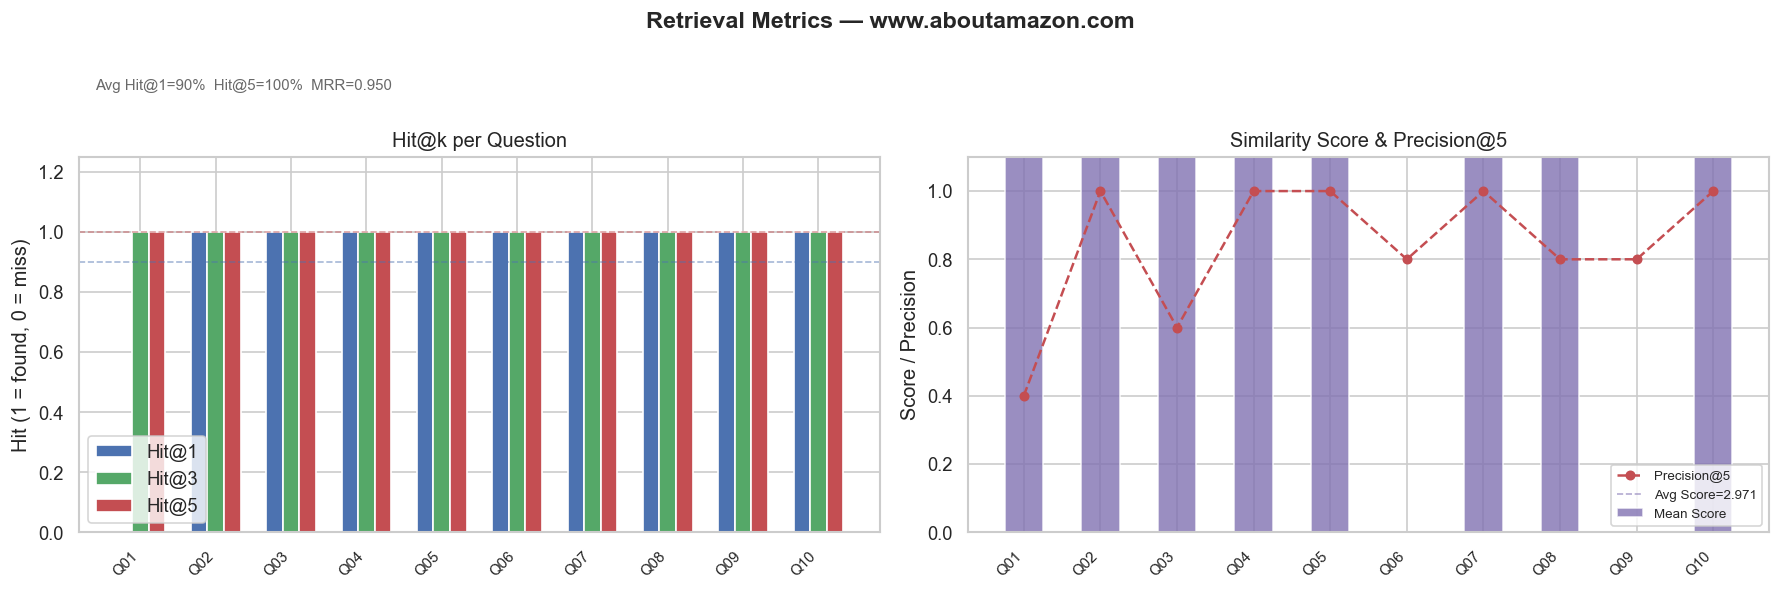

Saved: data/eval_retrieval_chart.png


In [6]:
labels  = [f'Q{r["idx"]:02d}' for r in retrieval_rows]
hit1    = [r['hit@1'] for r in retrieval_rows]
hit3    = [r['hit@3'] for r in retrieval_rows]
hit5    = [r['hit@5'] for r in retrieval_rows]
mrr     = [r['mrr@5'] for r in retrieval_rows]
scores  = [r['mean_score'] for r in retrieval_rows]
prec    = [r['precision@5'] for r in retrieval_rows]

x = np.arange(len(labels))
w = 0.22

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Retrieval Metrics — {SITE_LABEL}', fontsize=14, fontweight='bold')

# ── Left: Hit@k grouped bar ───────────────────────────────────────────────────
ax = axes[0]
ax.bar(x - w, hit1, w, label='Hit@1', color='#4C72B0')
ax.bar(x,     hit3, w, label='Hit@3', color='#55A868')
ax.bar(x + w, hit5, w, label='Hit@5', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.25)
ax.set_ylabel('Hit (1 = found, 0 = miss)')
ax.set_title('Hit@k per Question')
ax.legend()
ax.axhline(np.mean(hit1), color='#4C72B0', ls='--', lw=1, alpha=0.5)
ax.axhline(np.mean(hit5), color='#C44E52', ls='--', lw=1, alpha=0.5)
# Summary text
ax.text(0.02, 1.18, f'Avg Hit@1={np.mean(hit1):.0%}  Hit@5={np.mean(hit5):.0%}  MRR={np.mean(mrr):.3f}',
        transform=ax.transAxes, fontsize=9, color='dimgray')

# ── Right: Mean similarity score + Precision@5 line ──────────────────────────
ax2 = axes[1]
bars = ax2.bar(x, scores, 0.5, label='Mean Score', color='#8172B2', alpha=0.8)
ax2.plot(x, prec, 'o--', color='#C44E52', lw=1.5, ms=5, label='Precision@5')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Score / Precision')
ax2.set_title('Similarity Score & Precision@5')
ax2.axhline(np.mean(scores), color='#8172B2', ls='--', lw=1, alpha=0.6, label=f'Avg Score={np.mean(scores):.3f}')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_retrieval_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_retrieval_chart.png')

## 6. Charts — Faithfulness Metrics

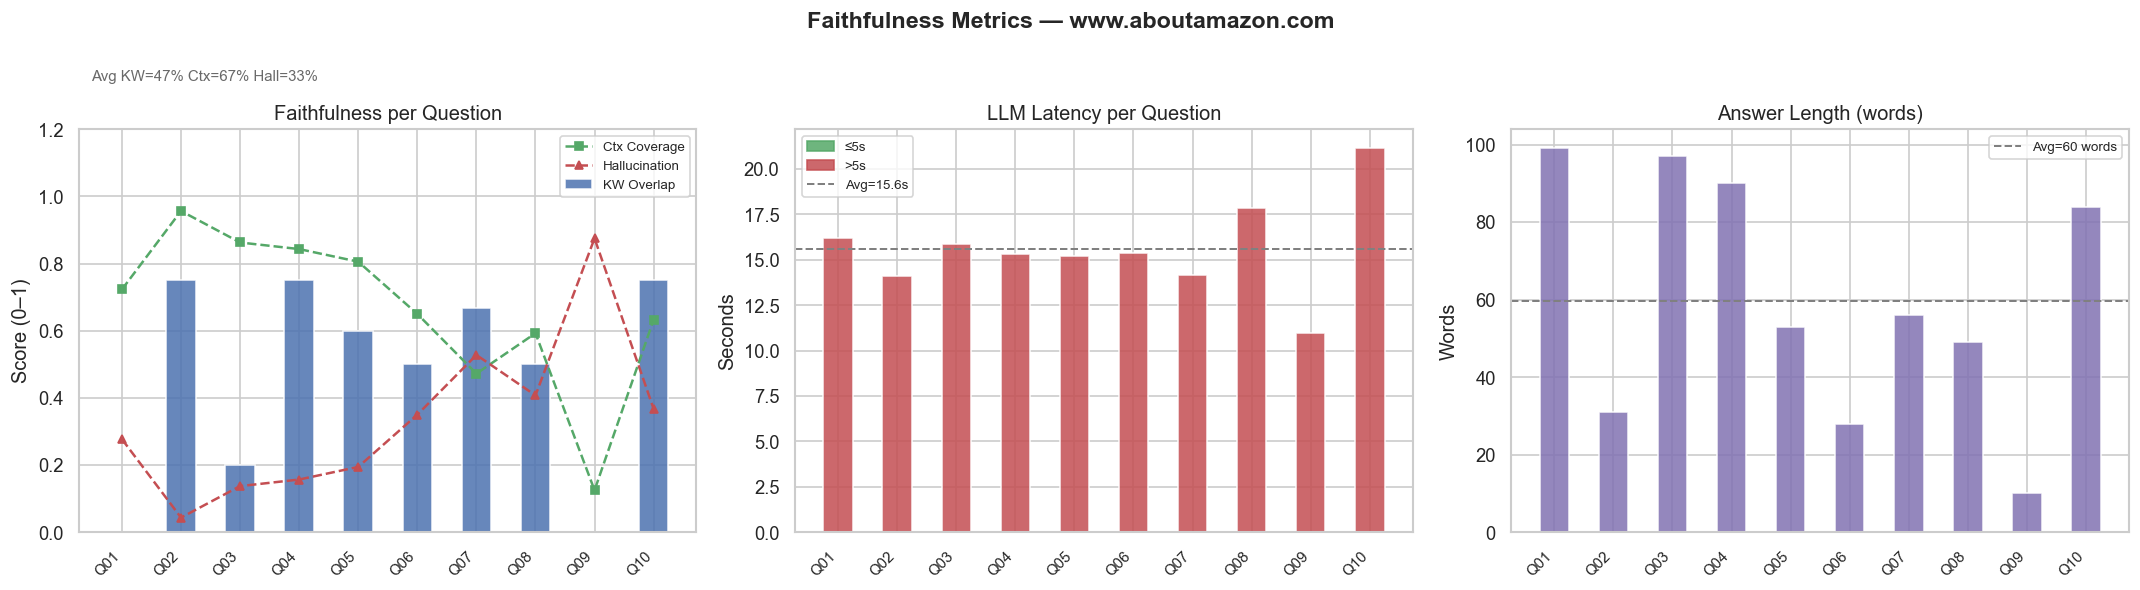

Saved: data/eval_faithfulness_chart.png


In [7]:
f_labels  = [f'Q{r["idx"]:02d}' for r in faithfulness_rows]
kw_ovlp   = [r['kw_overlap'] for r in faithfulness_rows]
ctx_cov   = [r['ctx_coverage'] for r in faithfulness_rows]
halluc    = [r['hallucination'] for r in faithfulness_rows]
latencies = [r['latency_s'] for r in faithfulness_rows]
words     = [r['answer_words'] for r in faithfulness_rows]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Faithfulness Metrics — {SITE_LABEL}', fontsize=14, fontweight='bold')
fx = np.arange(len(f_labels))

# ── Left: Keyword Overlap & Context Coverage stacked bars ────────────────────
ax = axes[0]
ax.bar(fx, kw_ovlp, 0.5, label='KW Overlap', color='#4C72B0', alpha=0.85)
ax.plot(fx, ctx_cov, 's--', color='#55A868', lw=1.5, ms=5, label='Ctx Coverage')
ax.plot(fx, halluc,  '^--', color='#C44E52', lw=1.5, ms=5, label='Hallucination')
ax.set_xticks(fx)
ax.set_xticklabels(f_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score (0–1)')
ax.set_title('Faithfulness per Question')
ax.legend(fontsize=8)
ax.text(0.02, 1.12, f'Avg KW={np.mean(kw_ovlp):.0%} Ctx={np.mean(ctx_cov):.0%} Hall={np.mean(halluc):.0%}',
        transform=ax.transAxes, fontsize=9, color='dimgray')

# ── Middle: LLM latency bar ───────────────────────────────────────────────────
ax = axes[1]
colors = ['#C44E52' if l > 5 else '#55A868' for l in latencies]
ax.bar(fx, latencies, 0.5, color=colors, alpha=0.85)
ax.axhline(np.mean(latencies), color='gray', ls='--', lw=1.2, label=f'Avg={np.mean(latencies):.1f}s')
ax.set_xticks(fx)
ax.set_xticklabels(f_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Seconds')
ax.set_title('LLM Latency per Question')
ax.legend(fontsize=8)
green_p = mpatches.Patch(color='#55A868', alpha=0.85, label='≤5s')
red_p   = mpatches.Patch(color='#C44E52', alpha=0.85, label='>5s')
ax.legend(handles=[green_p, red_p, ax.get_legend_handles_labels()[0][-1]], fontsize=8)

# ── Right: Answer length bar ──────────────────────────────────────────────────
ax = axes[2]
ax.bar(fx, words, 0.5, color='#8172B2', alpha=0.85)
ax.axhline(np.mean(words), color='gray', ls='--', lw=1.2, label=f'Avg={np.mean(words):.0f} words')
ax.set_xticks(fx)
ax.set_xticklabels(f_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Words')
ax.set_title('Answer Length (words)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_faithfulness_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_faithfulness_chart.png')

## 7. Eval Matrix Heatmap — All Metrics per Question

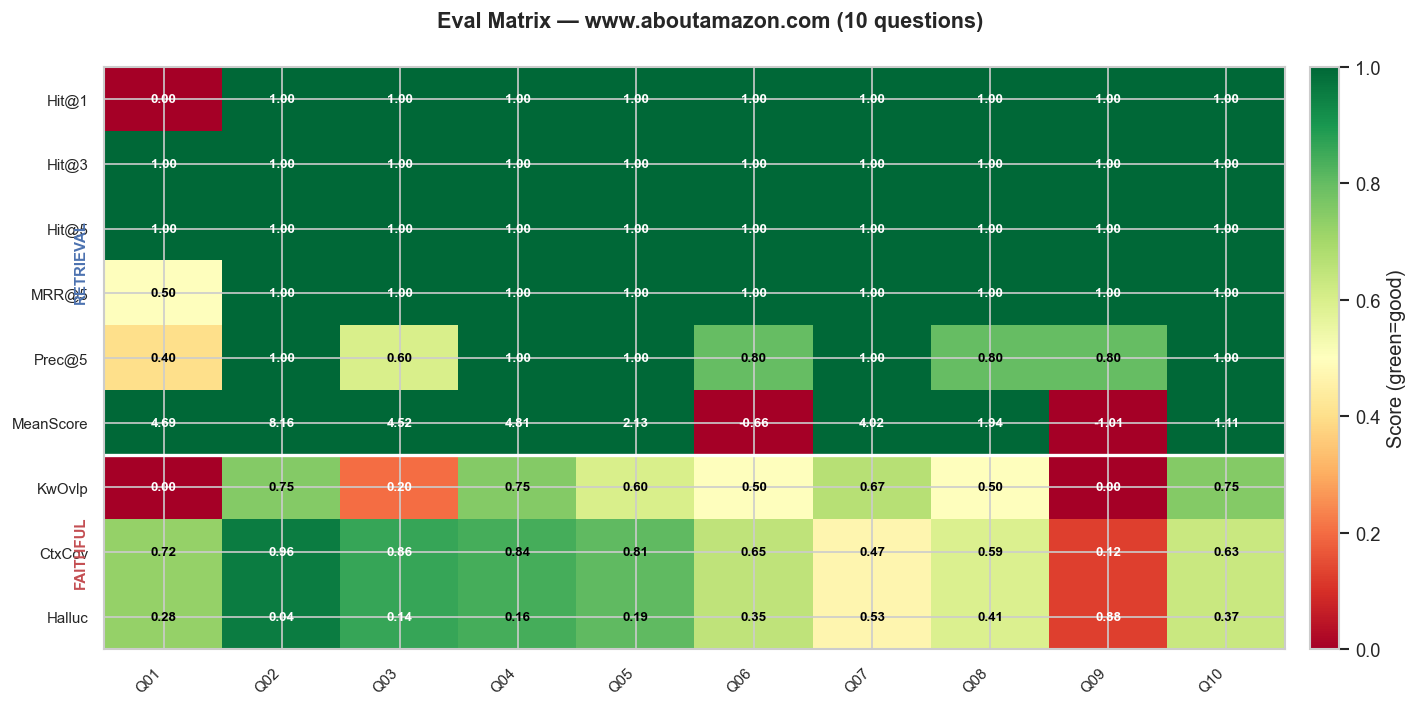

Saved: data/eval_matrix_heatmap.png


In [8]:
n = len(EVAL_QA)
metric_names = ['Hit@1', 'Hit@3', 'Hit@5', 'MRR@5', 'Prec@5', 'MeanScore', 'KwOvlp', 'CtxCov', 'Halluc']

matrix = np.array([
    [r['hit@1'] for r in retrieval_rows],
    [r['hit@3'] for r in retrieval_rows],
    [r['hit@5'] for r in retrieval_rows],
    [r['mrr@5'] for r in retrieval_rows],
    [r['precision@5'] for r in retrieval_rows],
    [r['mean_score'] for r in retrieval_rows],
    [r['kw_overlap'] for r in faithfulness_rows],
    [r['ctx_coverage'] for r in faithfulness_rows],
    [r['hallucination'] for r in faithfulness_rows],
])

# Invert Hallucination for display (lower halluc = greener = better)
display_matrix = matrix.copy()
display_matrix[8] = 1.0 - display_matrix[8]  # flip: high = good

row_labels = metric_names
col_labels = [f'Q{r["idx"]:02d}' for r in retrieval_rows]

fig, ax = plt.subplots(figsize=(max(12, n * 1.0), 6))
fig.suptitle(f'Eval Matrix — {SITE_LABEL} ({n} questions)', fontsize=13, fontweight='bold')

im = ax.imshow(display_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(len(metric_names)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticklabels(row_labels, fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Annotate cells
for i in range(len(metric_names)):
    for j in range(n):
        val = matrix[i, j]
        disp_val = display_matrix[i, j]
        text_color = 'black' if 0.3 < disp_val < 0.85 else 'white'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=text_color, fontweight='bold')

# Row separators between retrieval and faithfulness blocks
ax.axhline(5.5, color='white', lw=2)

# Labels for blocks
ax.text(-0.7, 2.5, 'RETRIEVAL', ha='center', va='center', rotation=90,
        fontsize=9, fontweight='bold', color='#4C72B0',
        transform=ax.transData)
ax.text(-0.7, 7.0, 'FAITHFUL', ha='center', va='center', rotation=90,
        fontsize=9, fontweight='bold', color='#C44E52',
        transform=ax.transData)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Score (green=good)')
plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_matrix_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_matrix_heatmap.png')

## 8. Radar Chart — Aggregate Profile

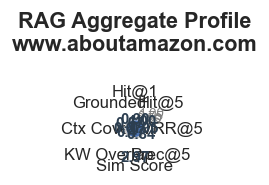

Saved: data/eval_radar_chart.png


In [9]:
radar_labels = ['Hit@1', 'Hit@5', 'MRR@5', 'Prec@5', 'Sim Score', 'KW Overlap', 'Ctx Cover', 'Grounded']
radar_vals = [
    np.mean(hit1),
    np.mean(hit5),
    np.mean(mrr),
    np.mean(prec),
    np.mean(scores),
    np.mean(kw_ovlp),
    np.mean(ctx_cov),
    1.0 - np.mean(halluc),   # grounded = 1 - hallucination
]

N = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
vals_plot = radar_vals + [radar_vals[0]]   # close polygon
angles_plot = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.plot(angles_plot, vals_plot, 'o-', lw=2, color='#4C72B0')
ax.fill(angles_plot, vals_plot, alpha=0.25, color='#4C72B0')

ax.set_thetagrids(np.degrees(angles), radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8, color='gray')
ax.set_title(f'RAG Aggregate Profile\n{SITE_LABEL}', size=13, fontweight='bold', pad=20)

# Annotate each spoke
for angle, val, label in zip(angles, radar_vals, radar_labels):
    ax.text(angle, val + 0.08, f'{val:.2f}', ha='center', va='center',
            fontsize=9, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_radar_chart.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_radar_chart.png')

## 9. Score Distribution Histograms

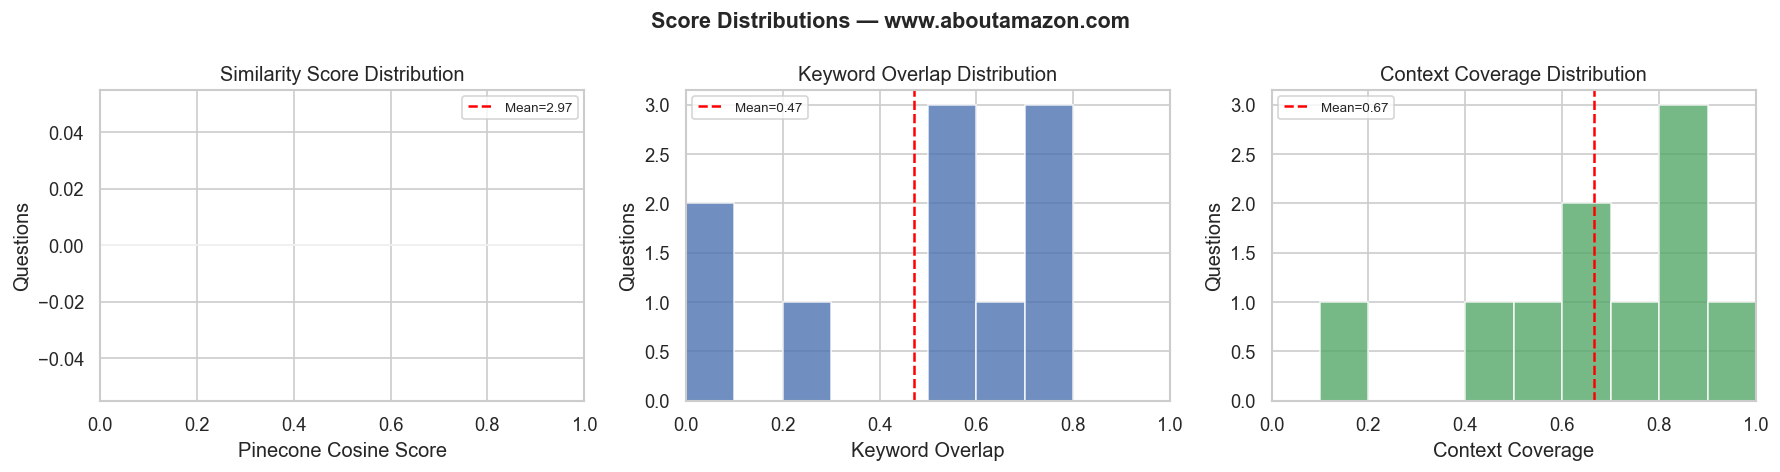

Saved: data/eval_distributions.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Score Distributions — {SITE_LABEL}', fontsize=13, fontweight='bold')

def hist(ax, data, title, color, xlabel):
    ax.hist(data, bins=10, range=(0, 1), color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(data), color='red', ls='--', lw=1.5, label=f'Mean={np.mean(data):.2f}')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Questions')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

hist(axes[0], scores,   'Similarity Score Distribution', '#8172B2', 'Pinecone Cosine Score')
hist(axes[1], kw_ovlp,  'Keyword Overlap Distribution',  '#4C72B0', 'Keyword Overlap')
hist(axes[2], ctx_cov,  'Context Coverage Distribution',  '#55A868', 'Context Coverage')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eval_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: data/eval_distributions.png')

## 10. Printed Metric Tables

In [11]:
# ── Retrieval table ───────────────────────────────────────────────────────────
print(f'RETRIEVAL TABLE — {SITE_LABEL}')
print('─' * 82)
print(f'{"Q#":<4} {"Hit@1":>6} {"Hit@3":>6} {"Hit@5":>6} {"MRR@5":>6} {"Prec@5":>7} {"Score":>6}  Question')
print('─' * 82)
for r in retrieval_rows:
    tag = '' if r['hit@5'] else ' ✗'
    print(f'Q{r["idx"]:02d}  {r["hit@1"]:>6} {r["hit@3"]:>6} {r["hit@5"]:>6} '
          f'{r["mrr@5"]:>6.2f} {r["precision@5"]:>7.0%} {r["mean_score"]:>6.3f}  {r["q"][:38]}{tag}')
print('─' * 82)
print(f'{"AVG":<4} {np.mean(hit1):>6.0%} {np.mean(hit3):>6.0%} {np.mean(hit5):>6.0%} '
      f'{np.mean(mrr):>6.3f} {np.mean(prec):>7.0%} {np.mean(scores):>6.3f}')
print()

# ── Faithfulness table ────────────────────────────────────────────────────────
print(f'FAITHFULNESS TABLE — {SITE_LABEL}')
print('─' * 82)
print(f'{"Q#":<4} {"KwOvlp":>7} {"CtxCov":>7} {"Halluc":>7} {"Words":>6} {"Src":>4} {"Lat(s)":>7}  Question')
print('─' * 82)
for r in faithfulness_rows:
    flag = ' !' if r['hallucination'] > 0.55 else ''
    print(f'Q{r["idx"]:02d}  {r["kw_overlap"]:>7.0%} {r["ctx_coverage"]:>7.0%} '
          f'{r["hallucination"]:>7.0%} {r["answer_words"]:>6} {r["num_sources"]:>4} '
          f'{r["latency_s"]:>7.1f}  {r["question"][:32]}{flag}')
print('─' * 82)
print(f'{"AVG":<4} {np.mean(kw_ovlp):>7.0%} {np.mean(ctx_cov):>7.0%} '
      f'{np.mean(halluc):>7.0%} {np.mean(words):>6.0f} '
      f'{np.mean([r["num_sources"] for r in faithfulness_rows]):>4.1f} '
      f'{np.mean(latencies):>7.1f}')

RETRIEVAL TABLE — www.aboutamazon.com
──────────────────────────────────────────────────────────────────────────────────
Q#    Hit@1  Hit@3  Hit@5  MRR@5  Prec@5  Score  Question
──────────────────────────────────────────────────────────────────────────────────
Q01       0      1      1   0.50     40%  4.687  What does Amazon do as a company?
Q02       1      1      1   1.00    100%  8.157  What is Amazon Web Services (AWS)?
Q03       1      1      1   1.00     60%  4.524  What kinds of products and services do
Q04       1      1      1   1.00    100%  4.812  What is Amazon’s approach to innovatio
Q05       1      1      1   1.00    100%  2.132  What industries does Amazon operate in
Q06       1      1      1   1.00     80% -0.661  How does Amazon combine retail and clo
Q07       1      1      1   1.00    100%  4.018  What principles guide Amazon’s innovat
Q08       1      1      1   1.00     80%  1.940  How does Amazon support third-party se
Q09       1      1      1   1.00     80% -1

## 11. Baseline Summary Box

In [12]:
print('╔' + '═' * 56 + '╗')
print(f'║  RAG BASELINE — {SITE_LABEL:<38} ║')
print('╠' + '═' * 56 + '╣')
print(f'║  Questions : {len(EVAL_QA):<42} ║')
print(f'║  Chunks    : {len(session["chunks"]):<42} ║')
print(f'║  Top-k     : {TOP_K:<42} ║')
print('╠' + '═' * 56 + '╣')
print('║  RETRIEVAL                                           ║')
print(f'║    Hit@1        : {np.mean(hit1):>6.1%}                             ║')
print(f'║    Hit@3        : {np.mean(hit3):>6.1%}                             ║')
print(f'║    Hit@5        : {np.mean(hit5):>6.1%}                             ║')
print(f'║    MRR@5        : {np.mean(mrr):>6.3f}                             ║')
print(f'║    Precision@5  : {np.mean(prec):>6.1%}                             ║')
print(f'║    Mean Score   : {np.mean(scores):>6.3f}                             ║')
print('╠' + '═' * 56 + '╣')
print('║  FAITHFULNESS                                        ║')
print(f'║    Keyword Overlap   : {np.mean(kw_ovlp):>6.1%}                        ║')
print(f'║    Context Coverage  : {np.mean(ctx_cov):>6.1%}                        ║')
print(f'║    Hallucination Est : {np.mean(halluc):>6.1%}                        ║')
print(f'║    Avg Answer Words  : {np.mean(words):>6.0f}                        ║')
print(f'║    Avg Latency       : {np.mean(latencies):>6.1f}s                       ║')
print('╚' + '═' * 56 + '╝')

╔════════════════════════════════════════════════════════╗
║  RAG BASELINE — www.aboutamazon.com                    ║
╠════════════════════════════════════════════════════════╣
║  Questions : 10                                         ║
║  Chunks    : 164                                        ║
║  Top-k     : 5                                          ║
╠════════════════════════════════════════════════════════╣
║  RETRIEVAL                                           ║
║    Hit@1        :  90.0%                             ║
║    Hit@3        : 100.0%                             ║
║    Hit@5        : 100.0%                             ║
║    MRR@5        :  0.950                             ║
║    Precision@5  :  84.0%                             ║
║    Mean Score   :  2.971                             ║
╠════════════════════════════════════════════════════════╣
║  FAITHFULNESS                                        ║
║    Keyword Overlap   :  47.2%                        ║
║    Context

## 12. Inspect Individual Answers

In [13]:
# Change Q_IDX to inspect any question (1-based)
Q_IDX = 1

rr = retrieval_rows[Q_IDX - 1]
fr = faithfulness_rows[Q_IDX - 1]

print(f'Q{Q_IDX:02d}: {rr["q"]}')
print(f'Ground truth : {rr["gt"]}')
print(f'Keywords     : {rr["kw"]}')
print()
print(f'RETRIEVAL  hit@1={rr["hit@1"]} hit@5={rr["hit@5"]} mrr={rr["mrr@5"]:.2f} score={rr["mean_score"]:.3f}')
print('Top chunks:')
for j, c in enumerate(rr['results'][:3], 1):
    print(f'  [{j}] score={c["score"]:.3f} | {c["chunk"]["section_title"]} | {c["chunk"]["text"][:120]}...')
print()
print(f'FAITHFULNESS  kw={fr["kw_overlap"]:.0%} ctx={fr["ctx_coverage"]:.0%} hall={fr["hallucination"]:.0%}')
print(f'ANSWER ({fr["answer_words"]} words):')
print(fr['answer'])

Q01: What does Amazon do as a company?
Ground truth : Amazon builds and operates businesses focused on e-commerce, cloud computing, devices, and digital services.
Keywords     : ['ecommerce', 'cloud', 'devices', 'services', 'businesses']

RETRIEVAL  hit@1=0 hit@5=1 mrr=0.50 score=4.687
Top chunks:
  [1] score=5.182 | Overview | Amazon’s culture of innovation and scale powers world-changing ideas and creates a safe, inclusive environment that allo...
  [2] score=4.883 | You might also like | Amazon Reports Dive deep into Amazon's support of employees and small businesses, and learn more about our efforts to bu...
  [3] score=4.490 | Overview | Amazon produces and delivers to customers world-class entertainment via Prime Video, Amazon MGM Studios, MGM+, Amazon Mu...

FAITHFULNESS  kw=0% ctx=72% hall=28%
ANSWER (99 words):
**Amazon’s Core Activities**

- **Entertainment production & delivery** – Provides movies, series, live events, sports, music, books and podcasts through Prime Video, A

## 13. Save Results

In [14]:
output = {
    'eval_date': datetime.datetime.utcnow().isoformat(),
    'site': SITE_LABEL,
    'session_id': SESSION_ID,
    'num_questions': len(EVAL_QA),
    'top_k': TOP_K,
    'retrieval_summary': {
        'hit@1': float(np.mean(hit1)),
        'hit@3': float(np.mean(hit3)),
        'hit@5': float(np.mean(hit5)),
        'mrr@5': float(np.mean(mrr)),
        'precision@5': float(np.mean(prec)),
        'mean_score': float(np.mean(scores)),
    },
    'faithfulness_summary': {
        'kw_overlap': float(np.mean(kw_ovlp)),
        'ctx_coverage': float(np.mean(ctx_cov)),
        'hallucination': float(np.mean(halluc)),
        'avg_words': float(np.mean(words)),
        'avg_latency_s': float(np.mean(latencies)),
    },
    'per_question': [
        {
            'idx': rr['idx'],
            'question': rr['q'],
            'ground_truth': rr['gt'],
            'keywords': rr['kw'],
            'hit@1': rr['hit@1'], 'hit@3': rr['hit@3'], 'hit@5': rr['hit@5'],
            'mrr@5': rr['mrr@5'], 'precision@5': rr['precision@5'], 'mean_score': rr['mean_score'],
            'answer': fr['answer'],
            'kw_overlap': fr['kw_overlap'],
            'ctx_coverage': fr['ctx_coverage'],
            'hallucination': fr['hallucination'],
            'answer_words': fr['answer_words'],
            'latency_s': fr['latency_s'],
        }
        for rr, fr in zip(retrieval_rows, faithfulness_rows)
    ],
}

out_path = DATA_DIR / f'eval_single_{SITE_LABEL}_{datetime.date.today()}.json'
out_path.write_text(json.dumps(output, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Results saved: {out_path}')
print(f'Charts saved : data/eval_retrieval_chart.png')
print(f'               data/eval_faithfulness_chart.png')
print(f'               data/eval_matrix_heatmap.png')
print(f'               data/eval_radar_chart.png')

Results saved: D:\dev\web-intelligence\data\eval_single_www.aboutamazon.com_2026-05-05.json
Charts saved : data/eval_retrieval_chart.png
               data/eval_faithfulness_chart.png
               data/eval_matrix_heatmap.png
               data/eval_radar_chart.png
